<a href="https://colab.research.google.com/github/Kanzacky/Dota-2-Win-Prediction-Robust-Data-Cleaning-via-IQR-Feature-Engineering/blob/main/Dota_2_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dota 2 Win Prediction: Robust Data Cleaning via IQR & Feature Engineering

Sel 1: Inisialisasi & Load Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/dota2Train.csv', header=None)
# Penamaan kolom (4 info + 113 hero)
kolom_info = ['target', 'cluster_id', 'game_mode', 'game_type']
kolom_hero = [f'hero_{i}' for i in range(1, 114)]
df.columns = kolom_info + kolom_hero

print("✅ Tahap 1: Load Data Selesai")
print(f"Total Data: {df.shape[0]} baris, {df.shape[1]} kolom")
display(df.head())

✅ Tahap 1: Load Data Selesai
Total Data: 92650 baris, 117 kolom


,target,cluster_id,game_mode,game_type,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,hero_9,hero_10,hero_11,hero_12,hero_13,hero_14,hero_15,hero_16,hero_17,hero_18,hero_19,hero_20,hero_21,hero_22,hero_23,hero_24,hero_25,hero_26,hero_27,hero_28,hero_29,hero_30,hero_31,hero_32,hero_33,hero_34,hero_35,hero_36,...,hero_74,hero_75,hero_76,hero_77,hero_78,hero_79,hero_80,hero_81,hero_82,hero_83,hero_84,hero_85,hero_86,hero_87,hero_88,hero_89,hero_90,hero_91,hero_92,hero_93,hero_94,hero_95,hero_96,hero_97,hero_98,hero_99,hero_100,hero_101,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_108,hero_109,hero_110,hero_111,hero_112,hero_113
0,-1,223,2,2,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,-1,0,0,0,-1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,152,2,2,0,0,0,1,0,-1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,1,0,0,0,0,0,0,0,-1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,131,2,2,0,0,0,1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,154,2,2,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0
4,-1,171,2,3,0,0,0,0,0,-1,0,0,-1,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Sel 2: Cleaning & Outlier (IQR)

In [ ]:
print("--- Memulai Tahap Cleaning ---")

# 1. Identifikasi Missing Values & Duplikat
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplikat awal : {df.duplicated().sum()}")
df = df.drop_duplicates()

# 2. Deteksi Outlier dengan metode IQR pada cluster_id
Q1 = df['cluster_id'].quantile(0.25)
Q3 = df['cluster_id'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['cluster_id'] < lower_bound) | (df['cluster_id'] > upper_bound)]
print(f"Outlier terdeteksi: {len(outliers)} baris")

# Penanganan: Kita simpan data yang tidak memiliki outlier
df_clean = df[(df['cluster_id'] >= lower_bound) & (df['cluster_id'] <= upper_bound)].copy()

print(f"✅ Tahap 2: Cleaning Selesai. Data sekarang: {len(df_clean)} baris")

--- Memulai Tahap Cleaning ---
Missing values: 0
Duplikat awal : 0
Outlier terdeteksi: 0 baris
✅ Tahap 2: Cleaning Selesai. Data sekarang: 92650 baris


Sel 2.5: Data Inspection

In [15]:
print("=" * 50)
print("INSPEKSI DATASET")
print("=" * 50)

# Informasi tipe data
print("\n📋 Informasi Tipe Data:")
df_clean.info()

# Statistik deskriptif hanya kolom info (bukan 113 hero)
print("\n📊 Statistik Deskriptif (Kolom Info):")
display(df_clean[kolom_info].describe().round(2))

# Visualisasi Missing Values (heatmap)
print("\n🔍 Visualisasi Missing Values:")
plt.figure(figsize=(10, 3))
sns.heatmap(df_clean[kolom_info].isnull(), cbar=True,
            yticklabels=False, cmap='viridis')
plt.title('Heatmap Missing Values — Kolom Info', fontsize=13)
plt.tight_layout()
plt.show()

print(f"✅ Total missing values: {df_clean.isnull().sum().sum()}")

INSPEKSI DATASET

📋 Informasi Tipe Data:


NameError: name 'df_clean' is not defined

Sel 3: Transformasi, Encoding & Scaling

In [ ]:
# 1. Encoding Target (-1 ke 0, 1 tetap 1)
df_clean['target'] = df_clean['target'].map({-1: 0, 1: 1})

# 2. Scaling pada kolom numerik (StandardScaler)
scaler = StandardScaler()
cols_to_scale = ['cluster_id', 'game_mode', 'game_type']
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("✅ Tahap 3 & 4: Transformasi, Encoding & Scaling Selesai")
display(df_clean[kolom_info].head())

✅ Tahap 3 & 4: Transformasi, Encoding & Scaling Selesai


,target,cluster_id,game_mode,game_type
0,0,1.321886,-0.500396,-0.789982
1,1,-0.669250,-0.500396,-0.789982
2,1,-1.258178,-0.500396,-0.789982
3,1,-0.613162,-0.500396,-0.789982
4,0,-0.136411,-0.500396,1.264122


Sel 4: EDA & Visualisasi

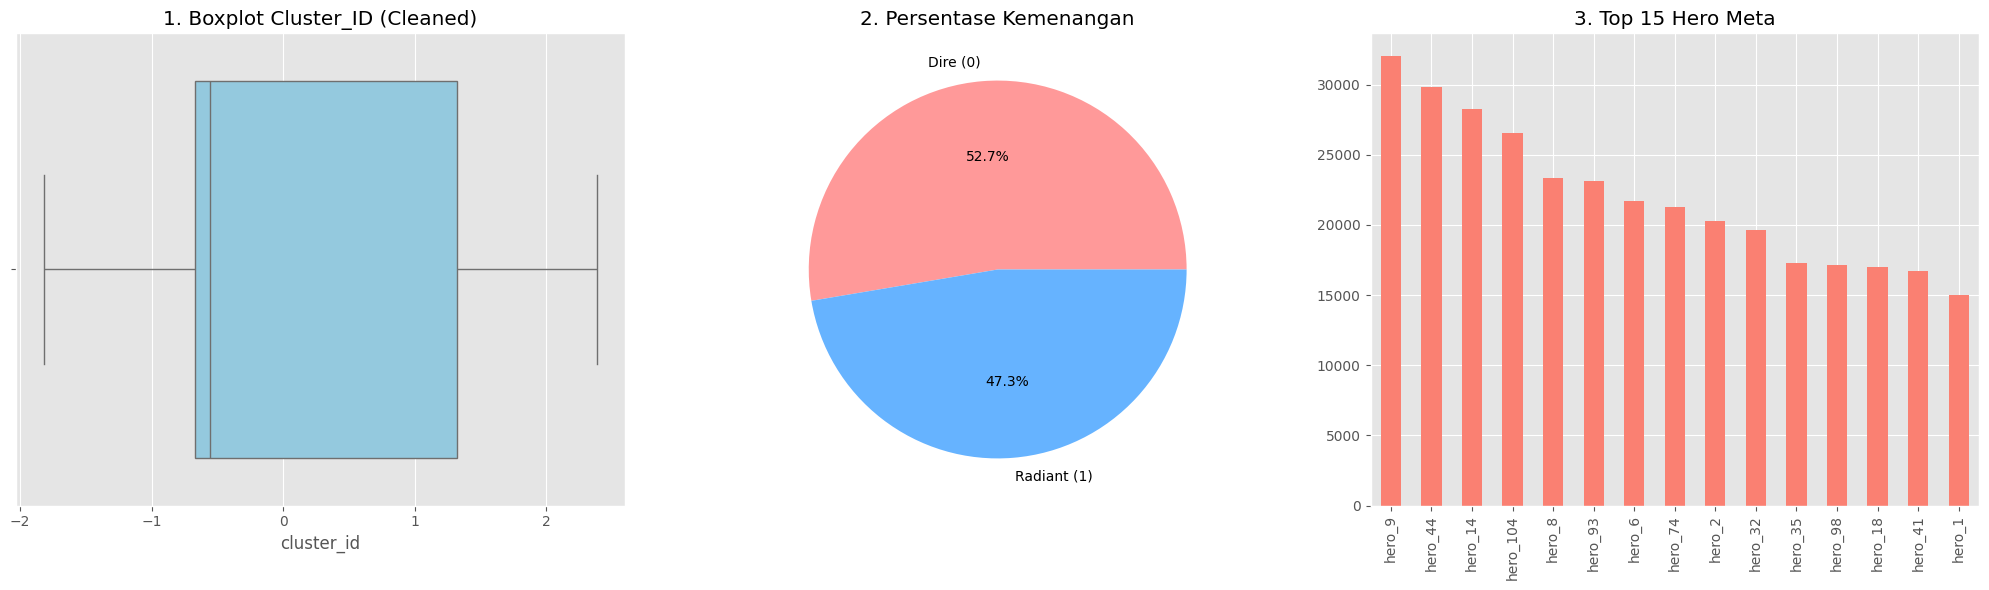


📌 3 INSIGHT UTAMA
1. Outlier pada Cluster_ID telah ditangani menggunakan metode IQR untuk kestabilan model.
2. Distribusi kemenangan Radiant vs Dire sangat seimbang (hampir 50:50).
3. Terdapat dominasi hero tertentu (Meta) yang jauh lebih sering muncul dibanding hero lainnya.


In [ ]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Visualisasi 1: Boxplot Cluster ID (Bukti Outlier bersih)
sns.boxplot(x=df_clean['cluster_id'], ax=ax[0], color='skyblue')
ax[0].set_title('1. Boxplot Cluster_ID (Cleaned)')

# Visualisasi 2: Pie Chart Target (Keseimbangan Data)
target_data = df_clean['target'].value_counts()
ax[1].pie(target_data, labels=['Dire (0)', 'Radiant (1)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
ax[1].set_title('2. Persentase Kemenangan')

# Visualisasi 3: Top 15 Hero Terpopuler
hero_picks = df_clean[kolom_hero].abs().sum().sort_values(ascending=False).head(15)
hero_picks.plot(kind='bar', ax=ax[2], color='salmon')
ax[2].set_title('3. Top 15 Hero Meta')

plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("📌 3 INSIGHT UTAMA")
print("="*30)
print("1. Outlier pada Cluster_ID telah ditangani menggunakan metode IQR untuk kestabilan model.")
print("2. Distribusi kemenangan Radiant vs Dire sangat seimbang (hampir 50:50).")
print("3. Terdapat dominasi hero tertentu (Meta) yang jauh lebih sering muncul dibanding hero lainnya.")

Sel 4.5: EDA Lanjutan — Target Analysis & Correlation

EDA LANJUTAN

📌 Analisis Win Rate per Game Mode:


,radiant_winrate,total_games,radiant_winrate_%
game_mode,,,
-0.500396,0.525154,71897,52.52
2.158111,0.521579,10033,52.16
1.778325,0.533229,8306,53.32
-0.880183,0.559805,1229,55.98
1.018751,0.632530,498,63.25
-0.120609,0.479275,386,47.93
0.259177,0.644231,208,64.42
1.398538,0.444444,81,44.44
0.638964,0.416667,12,41.67



📌 Analisis Win Rate per Game Type:


,radiant_winrate,total_games,radiant_winrate_%
game_type,,,
-2.844086,0.466667,15,46.67
-0.789982,0.527444,56988,52.74
1.264122,0.525065,35647,52.51


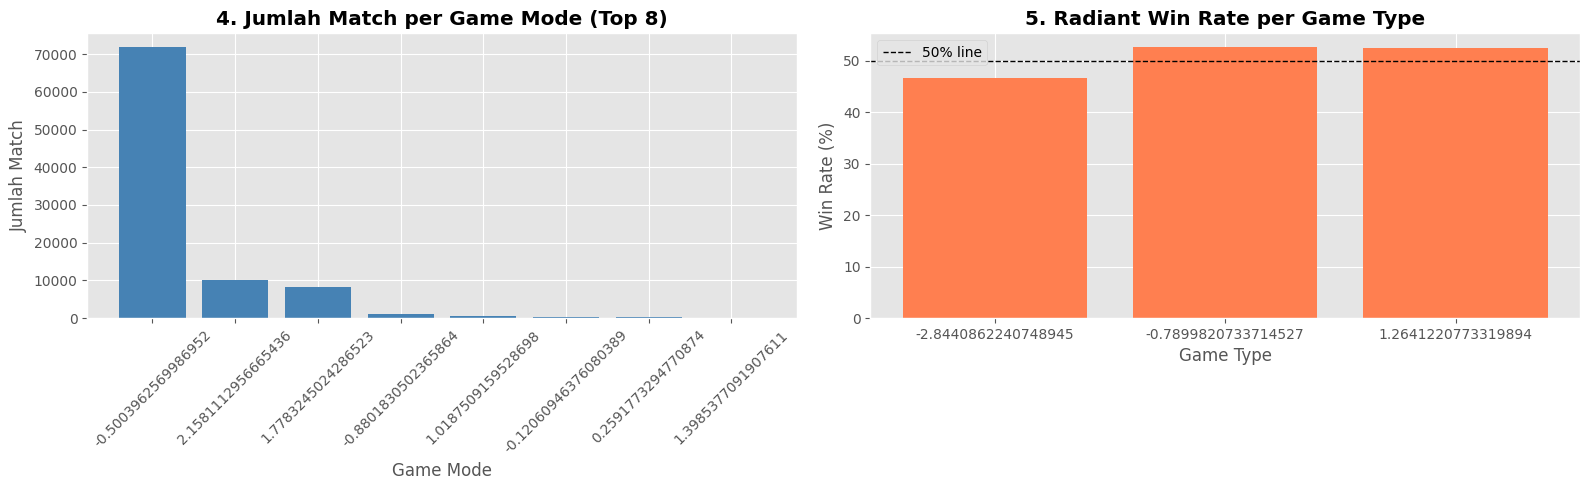


📌 Analisis Korelasi antar Kolom Info:


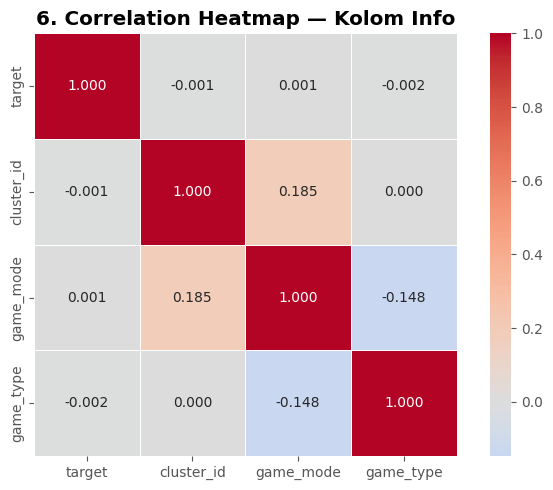


📌 INSIGHT TAMBAHAN
4. Game Mode tertentu mendominasi jumlah match yang dimainkan.
5. Win rate Radiant cenderung konsisten di sekitar 50% di berbagai game type.
6. Korelasi antar fitur info relatif rendah, menunjukkan masing-masing fitur membawa informasi unik.


In [ ]:
print("=" * 50)
print("EDA LANJUTAN")
print("=" * 50)

# --- Analisis 1: Target Distribution per Game Mode ---
print("\n📌 Analisis Win Rate per Game Mode:")
game_mode_analysis = df_clean.groupby('game_mode')['target'].agg(['mean', 'count'])
game_mode_analysis.columns = ['radiant_winrate', 'total_games']
game_mode_analysis['radiant_winrate_%'] = (game_mode_analysis['radiant_winrate'] * 100).round(2)
display(game_mode_analysis.sort_values('total_games', ascending=False).head(10))

# --- Analisis 2: Target Distribution per Game Type ---
print("\n📌 Analisis Win Rate per Game Type:")
game_type_analysis = df_clean.groupby('game_type')['target'].agg(['mean', 'count'])
game_type_analysis.columns = ['radiant_winrate', 'total_games']
game_type_analysis['radiant_winrate_%'] = (game_type_analysis['radiant_winrate'] * 100).round(2)
display(game_type_analysis)

# --- Visualisasi 4 & 5: Bar Chart Game Mode & Game Type ---
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

top_modes = game_mode_analysis.sort_values('total_games', ascending=False).head(8)
ax[0].bar(top_modes.index.astype(str), top_modes['total_games'], color='steelblue')
ax[0].set_title('4. Jumlah Match per Game Mode (Top 8)', fontweight='bold')
ax[0].set_xlabel('Game Mode')
ax[0].set_ylabel('Jumlah Match')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(game_type_analysis.index.astype(str),
          game_type_analysis['radiant_winrate_%'], color='coral')
ax[1].axhline(y=50, color='black', linestyle='--', linewidth=1, label='50% line')
ax[1].set_title('5. Radiant Win Rate per Game Type', fontweight='bold')
ax[1].set_xlabel('Game Type')
ax[1].set_ylabel('Win Rate (%)')
ax[1].legend()

plt.tight_layout()
plt.show()

# --- Visualisasi 6: Correlation Heatmap (kolom info) ---
print("\n📌 Analisis Korelasi antar Kolom Info:")
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df_clean[kolom_info].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('6. Correlation Heatmap — Kolom Info', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("📌 INSIGHT TAMBAHAN")
print("="*30)
print("4. Game Mode tertentu mendominasi jumlah match yang dimainkan.")
print("5. Win rate Radiant cenderung konsisten di sekitar 50% di berbagai game type.")
print("6. Korelasi antar fitur info relatif rendah, menunjukkan masing-masing fitur membawa informasi unik.")

Sel 5: Simpan Dataset Final

In [ ]:
# Simpan dataset yang sudah "siap tempur"
df_clean.to_csv('dota2_final_ready.csv', index=False)

print("✅ Dataset Final Berhasil Disimpan: 'dota2_final_ready.csv'")
print("Dataset ini siap digunakan untuk Modeling di pertemuan berikutnya.")

✅ Dataset Final Berhasil Disimpan: 'dota2_final_ready.csv'
Dataset ini siap digunakan untuk Modeling di pertemuan berikutnya.


MODUL 2 - MACHINE LEARNING: KLASIFIKASI

SEL 1: Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


 SEL 2: Load Dataset dari Modul 1

In [ ]:
df = pd.read_csv('/content/dota2_final_ready.csv')

print("=" * 60)
print("DOTA 2 DATASET - KLASIFIKASI")
print("=" * 60)
print(f"\nUkuran Dataset : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nDistribusi Target:")
print(df['target'].value_counts())
display(df.head())

DOTA 2 DATASET - KLASIFIKASI

Ukuran Dataset : 92650 baris x 117 kolom

Distribusi Target:
target
1    48782
0    43868
Name: count, dtype: int64


,target,cluster_id,game_mode,game_type,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,hero_9,hero_10,hero_11,hero_12,hero_13,hero_14,hero_15,hero_16,hero_17,hero_18,hero_19,hero_20,hero_21,hero_22,hero_23,hero_24,hero_25,hero_26,hero_27,hero_28,hero_29,hero_30,hero_31,hero_32,hero_33,hero_34,hero_35,hero_36,...,hero_74,hero_75,hero_76,hero_77,hero_78,hero_79,hero_80,hero_81,hero_82,hero_83,hero_84,hero_85,hero_86,hero_87,hero_88,hero_89,hero_90,hero_91,hero_92,hero_93,hero_94,hero_95,hero_96,hero_97,hero_98,hero_99,hero_100,hero_101,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_108,hero_109,hero_110,hero_111,hero_112,hero_113
0,0,1.321886,-0.500396,-0.789982,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,-1,0,0,0,-1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,-0.669250,-0.500396,-0.789982,0,0,0,1,0,-1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,1,0,0,0,0,0,0,0,-1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,-1.258178,-0.500396,-0.789982,0,0,0,1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,-0.613162,-0.500396,-0.789982,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0
4,0,-0.136411,-0.500396,1.264122,0,0,0,0,0,-1,0,0,-1,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


SEL 3: Pemisahan Fitur dan Target

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("=" * 60)
print("PEMISAHAN FITUR DAN TARGET")
print("=" * 60)
print(f"\nShape X (Features) : {X.shape}")
print(f"Shape y (Target)   : {y.shape}")
print(f"\nKeterangan Target:")
print("  0 = Dire Menang")
print("  1 = Radiant Menang")

PEMISAHAN FITUR DAN TARGET

Shape X (Features) : (92650, 116)
Shape y (Target)   : (92650,)

Keterangan Target:
  0 = Dire Menang
  1 = Radiant Menang


SEL 4: Train-Test Split 80:20

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("SPLIT DATA — 80% Training | 20% Testing")
print("=" * 60)
print(f"\nData Training : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Data Testing  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nDistribusi Target - Training:")
train_dist = y_train.value_counts()
print(f"  Dire menang    (0): {train_dist[0]}")
print(f"  Radiant menang (1): {train_dist[1]}")

print(f"\nDistribusi Target - Testing:")
test_dist = y_test.value_counts()
print(f"  Dire menang    (0): {test_dist[0]}")
print(f"  Radiant menang (1): {test_dist[1]}")

SPLIT DATA — 80% Training | 20% Testing

Data Training : 74120 samples (80%)
Data Testing  : 18530 samples (20%)

Distribusi Target - Training:
  Dire menang    (0): 35094
  Radiant menang (1): 39026

Distribusi Target - Testing:
  Dire menang    (0): 8774
  Radiant menang (1): 9756


SEL 5: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature Scaling Selesai")
print(f"   Mean X_train : {X_train_scaled.mean():.4f}")
print(f"   Std  X_train : {X_train_scaled.std():.4f}")

✅ Feature Scaling Selesai
   Mean X_train : -0.0000
   Std  X_train : 0.9913


SEL 6: Training Semua Model Klasifikasi

In [ ]:
from sklearn.svm import LinearSVC

models_dict = {
    "Naive Bayes"         : GaussianNB(),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42, max_depth=10),
    "SVM (Linear)"        : LinearSVC(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

needs_scaling = ["KNN", "Logistic Regression", "SVM (Linear)"]

results        = []
trained_models = {}

print("=" * 60)
print("TRAINING SEMUA MODEL ...")
print("=" * 60)

for name, model in models_dict.items():
    print(f"\n⏳ Training: {name} ...")

    if name in needs_scaling:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    trained_models[name] = {"model": model, "predictions": y_pred}
    results.append({"Model": name, "Accuracy": acc})

    print(f"   ✅ Accuracy: {acc:.4f} ({acc*100:.2f}%)")

print("\n✅ SEMUA MODEL SELESAI DITRAINING")

TRAINING SEMUA MODEL ...

⏳ Training: Naive Bayes ...
   ✅ Accuracy: 0.5567 (55.67%)

⏳ Training: KNN ...
   ✅ Accuracy: 0.5314 (53.14%)

⏳ Training: Logistic Regression ...
   ✅ Accuracy: 0.6073 (60.73%)

⏳ Training: Decision Tree ...
   ✅ Accuracy: 0.5515 (55.15%)

⏳ Training: SVM (Linear) ...
   ✅ Accuracy: 0.6074 (60.74%)

⏳ Training: Random Forest ...
   ✅ Accuracy: 0.5774 (57.74%)

✅ SEMUA MODEL SELESAI DITRAINING


SEL 7: Perbandingan Akurasi Semua Model

PERBANDINGAN AKURASI MODEL


,Model,Accuracy (%)
1,SVM (Linear),60.74
2,Logistic Regression,60.73
3,Random Forest,57.74
4,Naive Bayes,55.67
5,Decision Tree,55.15
6,KNN,53.14


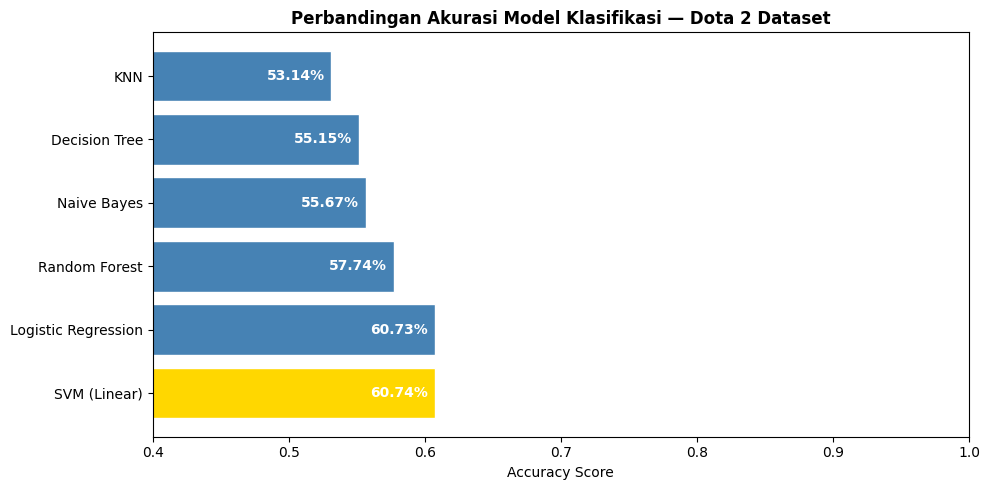

In [ ]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df.index += 1
results_df["Accuracy (%)"] = (results_df["Accuracy"] * 100).round(2)

print("=" * 60)
print("PERBANDINGAN AKURASI MODEL")
print("=" * 60)
display(results_df[["Model", "Accuracy (%)"]])

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = ax.barh(results_df["Model"], results_df["Accuracy"], color=colors, edgecolor='white')

for bar, acc in zip(bars, results_df["Accuracy"]):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc*100:.2f}%', va='center', ha='right', color='white', fontweight='bold')

ax.set_xlim([0.4, 1.0])
ax.set_xlabel("Accuracy Score")
ax.set_title("Perbandingan Akurasi Model Klasifikasi — Dota 2 Dataset", fontweight='bold')
plt.tight_layout()
plt.show()

SEL 8: Classification Report Model Terbaik

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_pred = trained_models[best_name]["predictions"]

print("=" * 60)
print(f"CLASSIFICATION REPORT — {best_name} (Model Terbaik)")
print("=" * 60)
print(classification_report(
    y_test, best_pred,
    target_names=["Dire Menang (0)", "Radiant Menang (1)"]
))

CLASSIFICATION REPORT — SVM (Linear) (Model Terbaik)
                    precision    recall  f1-score   support

   Dire Menang (0)       0.60      0.52      0.56      8774
Radiant Menang (1)       0.61      0.69      0.65      9756

          accuracy                           0.61     18530
         macro avg       0.61      0.60      0.60     18530
      weighted avg       0.61      0.61      0.60     18530



SEL 9: Confusion Matrix Semua Model

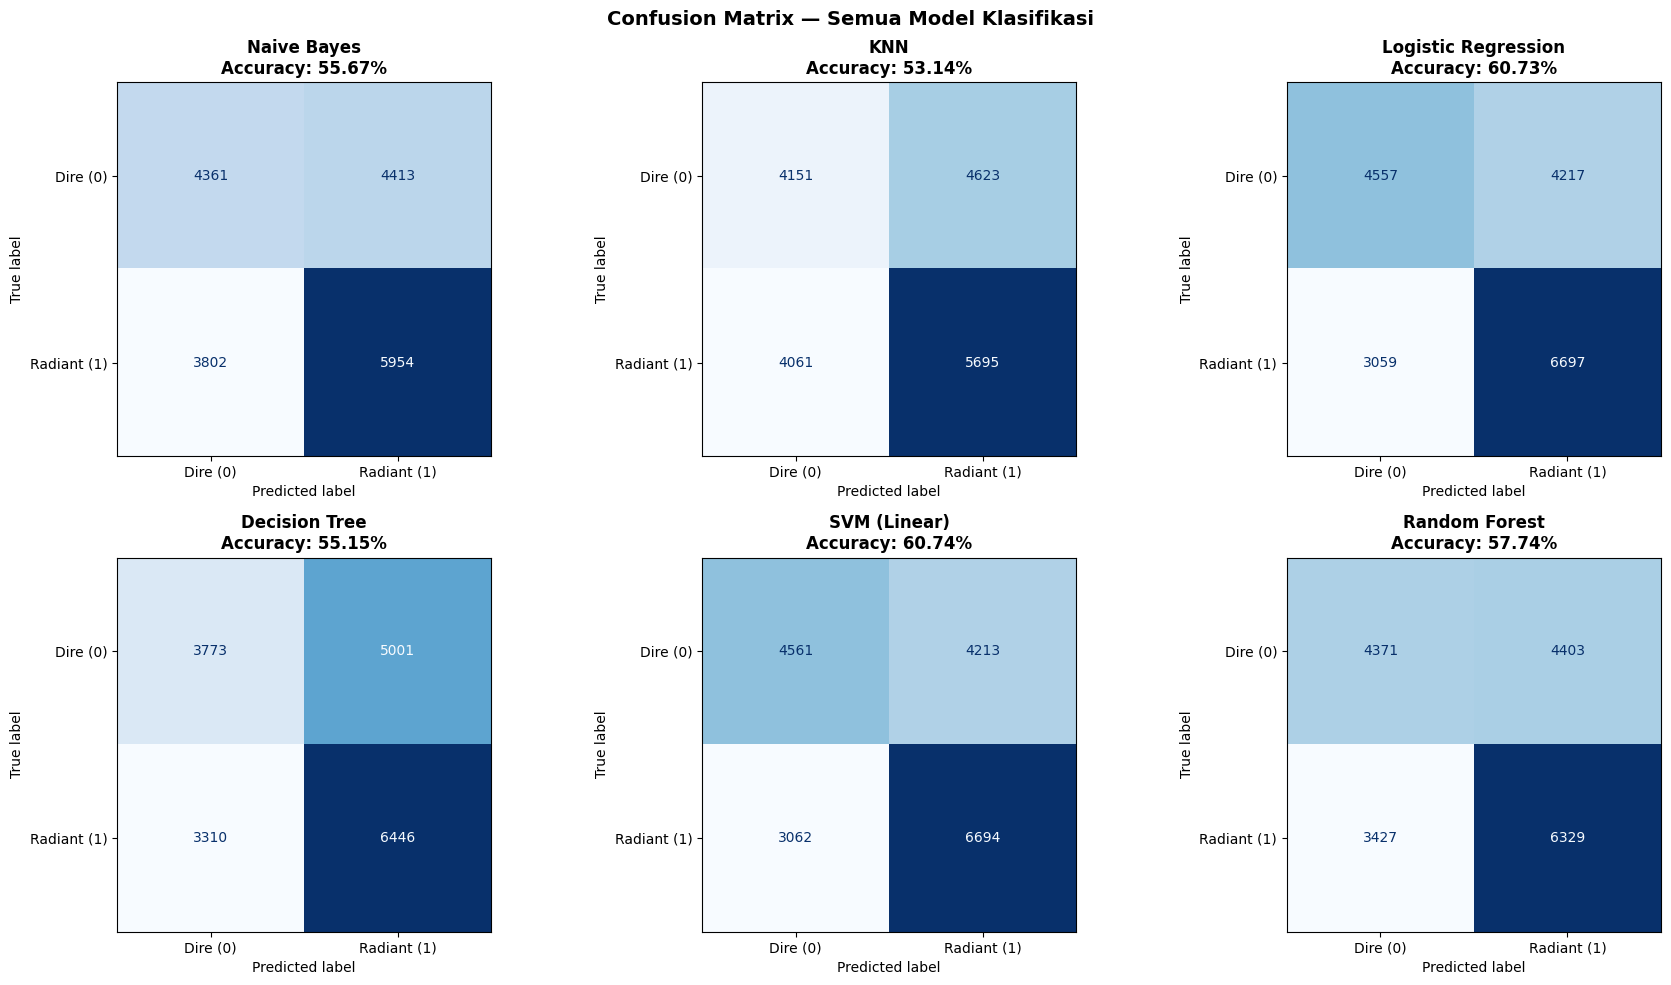

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, data["predictions"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Dire (0)", "Radiant (1)"])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test, data["predictions"])
    axes[idx].set_title(f"{name}\nAccuracy: {acc*100:.2f}%", fontweight='bold')

plt.suptitle("Confusion Matrix — Semua Model Klasifikasi", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SEL 10: Contoh Prediksi (10 data pertama)

In [ ]:
print("=" * 60)
print(f"CONTOH PREDIKSI — {best_name}")
print("=" * 60)

comparison = pd.DataFrame({
    "Actual"   : y_test.values[:10],
    "Predicted": best_pred[:10],
})
comparison["Actual Label"]    = comparison["Actual"].map({0: "Dire Menang", 1: "Radiant Menang"})
comparison["Predicted Label"] = comparison["Predicted"].map({0: "Dire Menang", 1: "Radiant Menang"})
comparison["Hasil"] = comparison.apply(
    lambda row: "✅ Benar" if row["Actual"] == row["Predicted"] else "❌ Salah", axis=1
)

display(comparison[["Actual Label", "Predicted Label", "Hasil"]])
print(f"\nDari 10 prediksi pertama: {(comparison['Hasil'] == '✅ Benar').sum()}/10 benar")

CONTOH PREDIKSI — SVM (Linear)


,Actual Label,Predicted Label,Hasil
0,Radiant Menang,Radiant Menang,✅ Benar
1,Radiant Menang,Radiant Menang,✅ Benar
2,Dire Menang,Radiant Menang,❌ Salah
3,Dire Menang,Radiant Menang,❌ Salah
4,Dire Menang,Radiant Menang,❌ Salah
5,Radiant Menang,Dire Menang,❌ Salah
6,Radiant Menang,Dire Menang,❌ Salah
7,Radiant Menang,Radiant Menang,✅ Benar
8,Dire Menang,Radiant Menang,❌ Salah
9,Radiant Menang,Radiant Menang,✅ Benar



Dari 10 prediksi pertama: 4/10 benar


 SEL 11: Simpan Model Terbaik (.pkl)

In [ ]:
best_model_obj = trained_models[best_name]["model"]
filename = f'best_model_{best_name.lower().replace(" ", "_")}.pkl'

with open(filename, 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"✅ Model '{best_name}' berhasil disimpan sebagai: '{filename}'")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy (%)']:.2f}%")
print(f"\n📌 Cara load model:")
print(f"   import pickle")
print(f"   with open('{filename}', 'rb') as f:")
print(f"       model = pickle.load(f)")

✅ Model 'SVM (Linear)' berhasil disimpan sebagai: 'best_model_svm_(linear).pkl'
   Accuracy: 60.74%

📌 Cara load model:
   import pickle
   with open('best_model_svm_(linear).pkl', 'rb') as f:
       model = pickle.load(f)
